# direct methods

In [2]:
using Logging

global_logger(ConsoleLogger(stderr, Logging.Info; show_limited=false))

ConsoleLogger(VSCodeServer.IJuliaCore.IJuliaStdio{Base.PipeEndpoint, typeof(VSCodeServer.io_send_callback)}(IOContext(Base.PipeEndpoint(Base.Libc.WindowsRawSocket(0x0000000000000354) open, 0 bytes waiting)), VSCodeServer.io_send_callback), Info, Base.CoreLogging.default_metafmt, false, 0, Dict{Any, Int64}())

In [3]:
using Plots, Optim, LinearAlgebra

> wheeler's ridge is a two-dimensional function with a single global
minimum in a deep curved peak. The function has two ridges, one along the
positive and one along the negative first coordinate axis. A gradient descent
method will diverge along the negative axis ridge. The function is very flat away
from the optimum and the ridge.

> the optimum for $a=1.5$ is at $[1, 3/2]$

In [4]:
wheeler(x, a=1.5) = -exp(-(x[1]*x[2] - a)^2 -(x[2]-a)^2) 

wheeler (generic function with 2 methods)

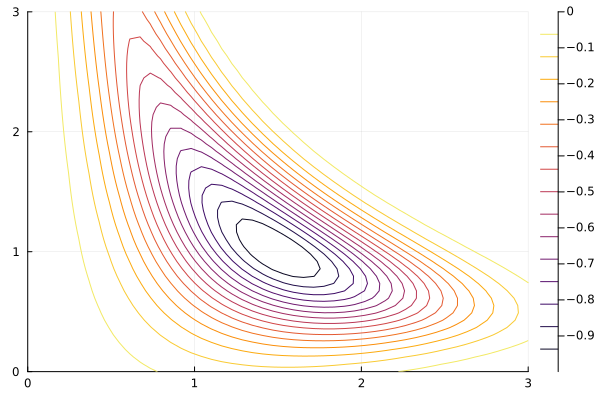

In [5]:
x1=x2=range(0,3,50)
y = [wheeler([x_1,x_2]) for x_1 in x1, x_2 in x2]
plot(x1,x2,y)


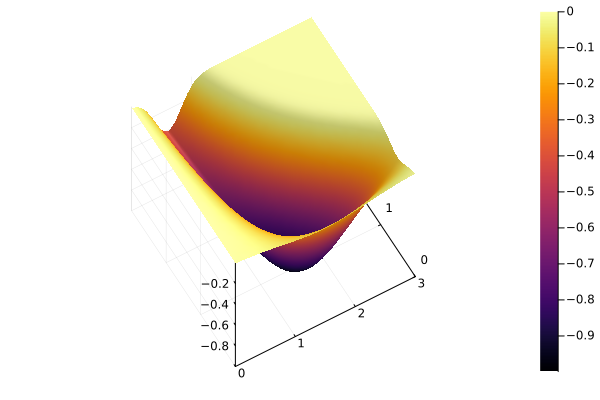

In [11]:
plot(x1,x2,y,st=:surface,camera=(-30,60))

## Cyclic coordinate search

In [6]:
basis(i, n) = [k == i ? 1.0 : 0.0 for k in 1 : n] 

basis (generic function with 1 method)

In [7]:
function bracket_minimum(f, x=0; s=1e-2, k=2.0)
  a, ya = x, f(x)
  b, yb = a + s, f(a + s)
  if yb > ya
      a, b = b, a
      ya, yb = yb, ya
      s = -s
  end
  while true
      c, yc = b + s, f(b + s)
      if yc > yb
          return a < c ? (a, c) : (c, a)
      end
      a, ya, b, yb = b, yb, c, yc
      s *= k
  end
end

function line_search(f, x, d)
    objective = α -> f(x + α * d)
    a, b = bracket_minimum(objective)
  
    # Use Optim.jl to minimize the objective function
    result = optimize(objective, a, b, Brent())  # Brent's method for 1D minimization
    α = Optim.minimizer(result)  # Extract the minimizing α value
  
    return x + α * d
  end

line_search (generic function with 1 method)

In [8]:
function cyclic_coordinate_descent(f, x, ϵ)
    Δ, n = Inf, length(x)
    while abs(Δ) > ϵ
        x′ = copy(x)
        for i in 1:n
            d = basis(i, n)
            x = line_search(f, x, d)
            @info d, x
        end
        Δ = norm(x - x′)
    end
    return x
end

cyclic_coordinate_descent (generic function with 1 method)

In [26]:
cyclic_coordinate_descent(wheeler,  [4.5,4.2], 10^(-5))

2-element Vector{Float64}:
 0.9999956661853819
 1.500003250288727

In [15]:
function cyclic_coordinate_descent_with_acceleration_step(f, x, ϵ)
    Δ, n = Inf, length(x)
    while abs(Δ) > ϵ
        x′ = copy(x)
        for i in 1:n
            d = basis(i, n)
            x = line_search(f, x, d)
            @info d,x
        end
        x = line_search(f, x, x - x′) # acceleration step
        @info "acceleration ",x
        Δ = norm(x - x′)
    end
    return x
end

cyclic_coordinate_descent_with_acceleration_step (generic function with 1 method)

In [25]:
cyclic_coordinate_descent_with_acceleration_step(wheeler,  [4.5,4.2], 10^(-4))

2-element Vector{Float64}:
 1.0000165101616851
 1.499982442390153

## Powell's  method

In [17]:
function powell(f, x, ϵ)
    n = length(x)
    U = [basis(i, n) for i in 1:n]
    Δ = Inf
    while Δ > ϵ
        x′ = x
        for i in 1:n
            d = U[i]
            x′ = line_search(f, x′, d)
        end
        for i in 1:n-1
            U[i] = U[i+1]
        end
        U[n] = d = x′ - x
        x′ = line_search(f, x, d)
        Δ = norm(x′ - x)
        x = x′
        @info U,x
    end
    return x
end

powell (generic function with 1 method)

In [24]:
powell(wheeler,  [4.5,4.2], 10^(-4)) 

[ Info: ([[0.0, 1.0], [-4.14285714445666, -2.39457013275739]], [-3.304972766116582, -0.3112718158131784])
[ Info: ([[-4.14285714445666, -2.39457013275739], [-0.03357382387323016, 0.0018800692114359085]], [-5.9841027062050625, -0.16124572010197])
[ Info: ([[-0.03357382387323016, 0.0018800692114359085], [-0.8797205814334719, 0.002646177598502081]], [-10.43206863690459, -0.14786634936411752])
[ Info: ([[-0.8797205814334719, 0.002646177598502081], [-3.7909761306078185, 0.03737349299831068]], [-17.754263280513182, -0.07568019444857665])
[ Info: ([[-3.7909761306078185, 0.03737349299831068], [-7.666852285394029, 0.019773102766577733]], [-28.91776498711804, -0.046889100233798886])
[ Info: ([[-7.666852285394029, 0.019773102766577733], [-1.5567048147142835, 0.0015947648568408468]], [-43.9458784685311, -0.031493562802270836])
[ Info: ([[-1.5567048147142835, 0.0015947648568408468], [-2.246987301324843, 0.0010338777767386897]], [-65.21523401335372, -0.021707163915912868])
[ Info: ([[-2.246987301324

2-element Vector{Float64}:
 -5.803295644065678e9
 -2.5847379792054317e-10

## Hooke-Jeeves

In [20]:
function hooke_jeeves(f, x, α, ϵ, γ=0.5)
    y, n = f(x), length(x)
    while α > ϵ
        improved = false
        x_best, y_best = x, y
        for i in 1:n
            for sgn in (-1, 1)
                x′ = x + sgn * α * basis(i, n)
                y′ = f(x′)
                if y′ < y_best
                    x_best, y_best, improved = x′, y′, true
                end
            end
        end
        x, y = x_best, y_best
        if !improved
            α *= γ
        end
        @info x, y, α
    end
    return x
end

hooke_jeeves (generic function with 2 methods)

In [31]:
x=hooke_jeeves(wheeler, [4.5,4.2], 3, 10^(-4)) 
x

2-element Vector{Float64}:
 0.99993896484375
 1.5001098632812502

##TODO:

Benchmark the implementations above by reporting, for 30 independent runs starting at different initial points. Compute:
- distance from the result to the real optimum;
- number of iterations required to reach convergence by each method;
- compare results by using descriptive statistics: mean and standard deviation of values;
- create a boxplot presenting the number of iterations to convergence for each method over the 30 runs; which one required less iterations? are there significant differences among results?